In [62]:
import os
import re
import torch
import sys
from torch.utils.data import Dataset,DataLoader,random_split
from PIL import Image
import torchvision.transforms as transforms
import tqdm
import numpy as np
import torch.nn as nn 
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
import random

sys.path.append(os.path.abspath("../CustomDataset"))
from CustomDataset import CustomDataset,convert_to_ela_image

In [63]:
#Load dataset
SIZE = 64
dataset = CustomDataset("../CASIA/Au","../CASIA/Gt","../CASIA/Tp",n=SIZE)
#Splitting into train and test
train_ratio = 0.8
train_size = int(train_ratio*len(dataset))
test_size = len(dataset)-train_size
train_ds,test_ds = random_split(dataset,[train_size,test_size])




 39%|███▉      | 358/921 [00:11<00:18, 31.23it/s]

Mask not found for Sp_D_NRN_A_cha0011_sec0011_0542.jpg


100%|██████████| 921/921 [00:27<00:00, 33.02it/s]


In [64]:
train_dataloader = DataLoader(train_ds,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_ds,batch_size=64,shuffle=True)


In [65]:
class DualConv(nn.Module):
    def __init__(self,input_ch,output_ch):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(input_ch,output_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(output_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_ch,output_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(output_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv_block(x)
    
#Contraction
class Contract(nn.Module):
    def __init__(self,input_ch,output_ch):
        super().__init__()
        self.down_conv = nn.Sequential(nn.MaxPool2d(2),DualConv(input_ch,output_ch))

    def forward(self,x):
        return self.down_conv(x)

#Expansion
class Expand(nn.Module):
    def __init__(self,input_ch,output_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(input_ch,input_ch//2,kernel_size=2,stride=2)
        self.conv = DualConv(input_ch,output_ch)
    
    def forward(self,x1,x2):
        x1 = self.up(x1)

        #Ensuring both have the same size
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        x1 = F.pad(
            x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2]
        )
        #Concat
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)
    
#Final Convolution operation
class FinalConv(nn.Module):
    def __init__(self,input_ch,output_ch):
        super().__init__()
        self.conv = nn.Conv2d(input_ch,output_ch,kernel_size=1)
    
    def forward(self,x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self,input_channels,num_classes):
        super().__init__()
        self.inital = DualConv(input_channels,16)
        self.down1 = Contract(16,32)
        self.down2 = Contract(32,64)
        self.up1 = Expand(64,32)
        self.up2 = Expand(32,16)
        self.final = FinalConv(16,num_classes)
    
    def forward(self,x):
        x1 = self.inital(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.up1(x3,x2)
        x = self.up2(x,x1)
        logits = self.final(x)
        return logits


In [66]:
#Custom loss which penalizes missed maps
class WeightedBCELoss(nn.Module):
    def __init__(self,pos_weight=10.0):
        super().__init__()
        self.pos_weights = pos_weight
    
    def forward(self,preds,targets):
        eps = 1e-7
        preds = torch.clamp(preds,eps,1-eps)

        loss = ((-self.pos_weights)*targets*torch.log(preds) - (1-targets)*torch.log(1-preds))
        return loss.mean()        

#Dice Loss
def dice_loss(pred, target, smooth=1.0):
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)
    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)
    dice = (2 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

In [69]:
model = UNet(6,1)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

num_epochs = 15


In [70]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images,masks in tqdm.tqdm(train_dataloader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = dice_loss(outputs,masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_dataloader)}")

    #Testing loss
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for images, masks in test_dataloader:
            outputs = model(images)
            loss = dice_loss(outputs, masks)
            test_loss += loss.item()

    print(f"Validation Loss: {test_loss/len(test_dataloader):.4f}")
    

100%|██████████| 22/22 [00:20<00:00,  1.09it/s]


Epoch [1/15], Loss: 0.9216055599125949
Validation Loss: 0.9174


100%|██████████| 22/22 [00:18<00:00,  1.17it/s]


Epoch [2/15], Loss: 0.9152784645557404
Validation Loss: 0.9149


100%|██████████| 22/22 [00:18<00:00,  1.19it/s]


...

Epoch [13/15], Loss: 0.8851578723300587
Validation Loss: 0.8863


100%|██████████| 22/22 [00:17<00:00,  1.23it/s]


Epoch [14/15], Loss: 0.8828954669562253
Validation Loss: 0.8876


100%|██████████| 22/22 [00:17<00:00,  1.23it/s]


Epoch [15/15], Loss: 0.8827066258950667
Validation Loss: 0.8885


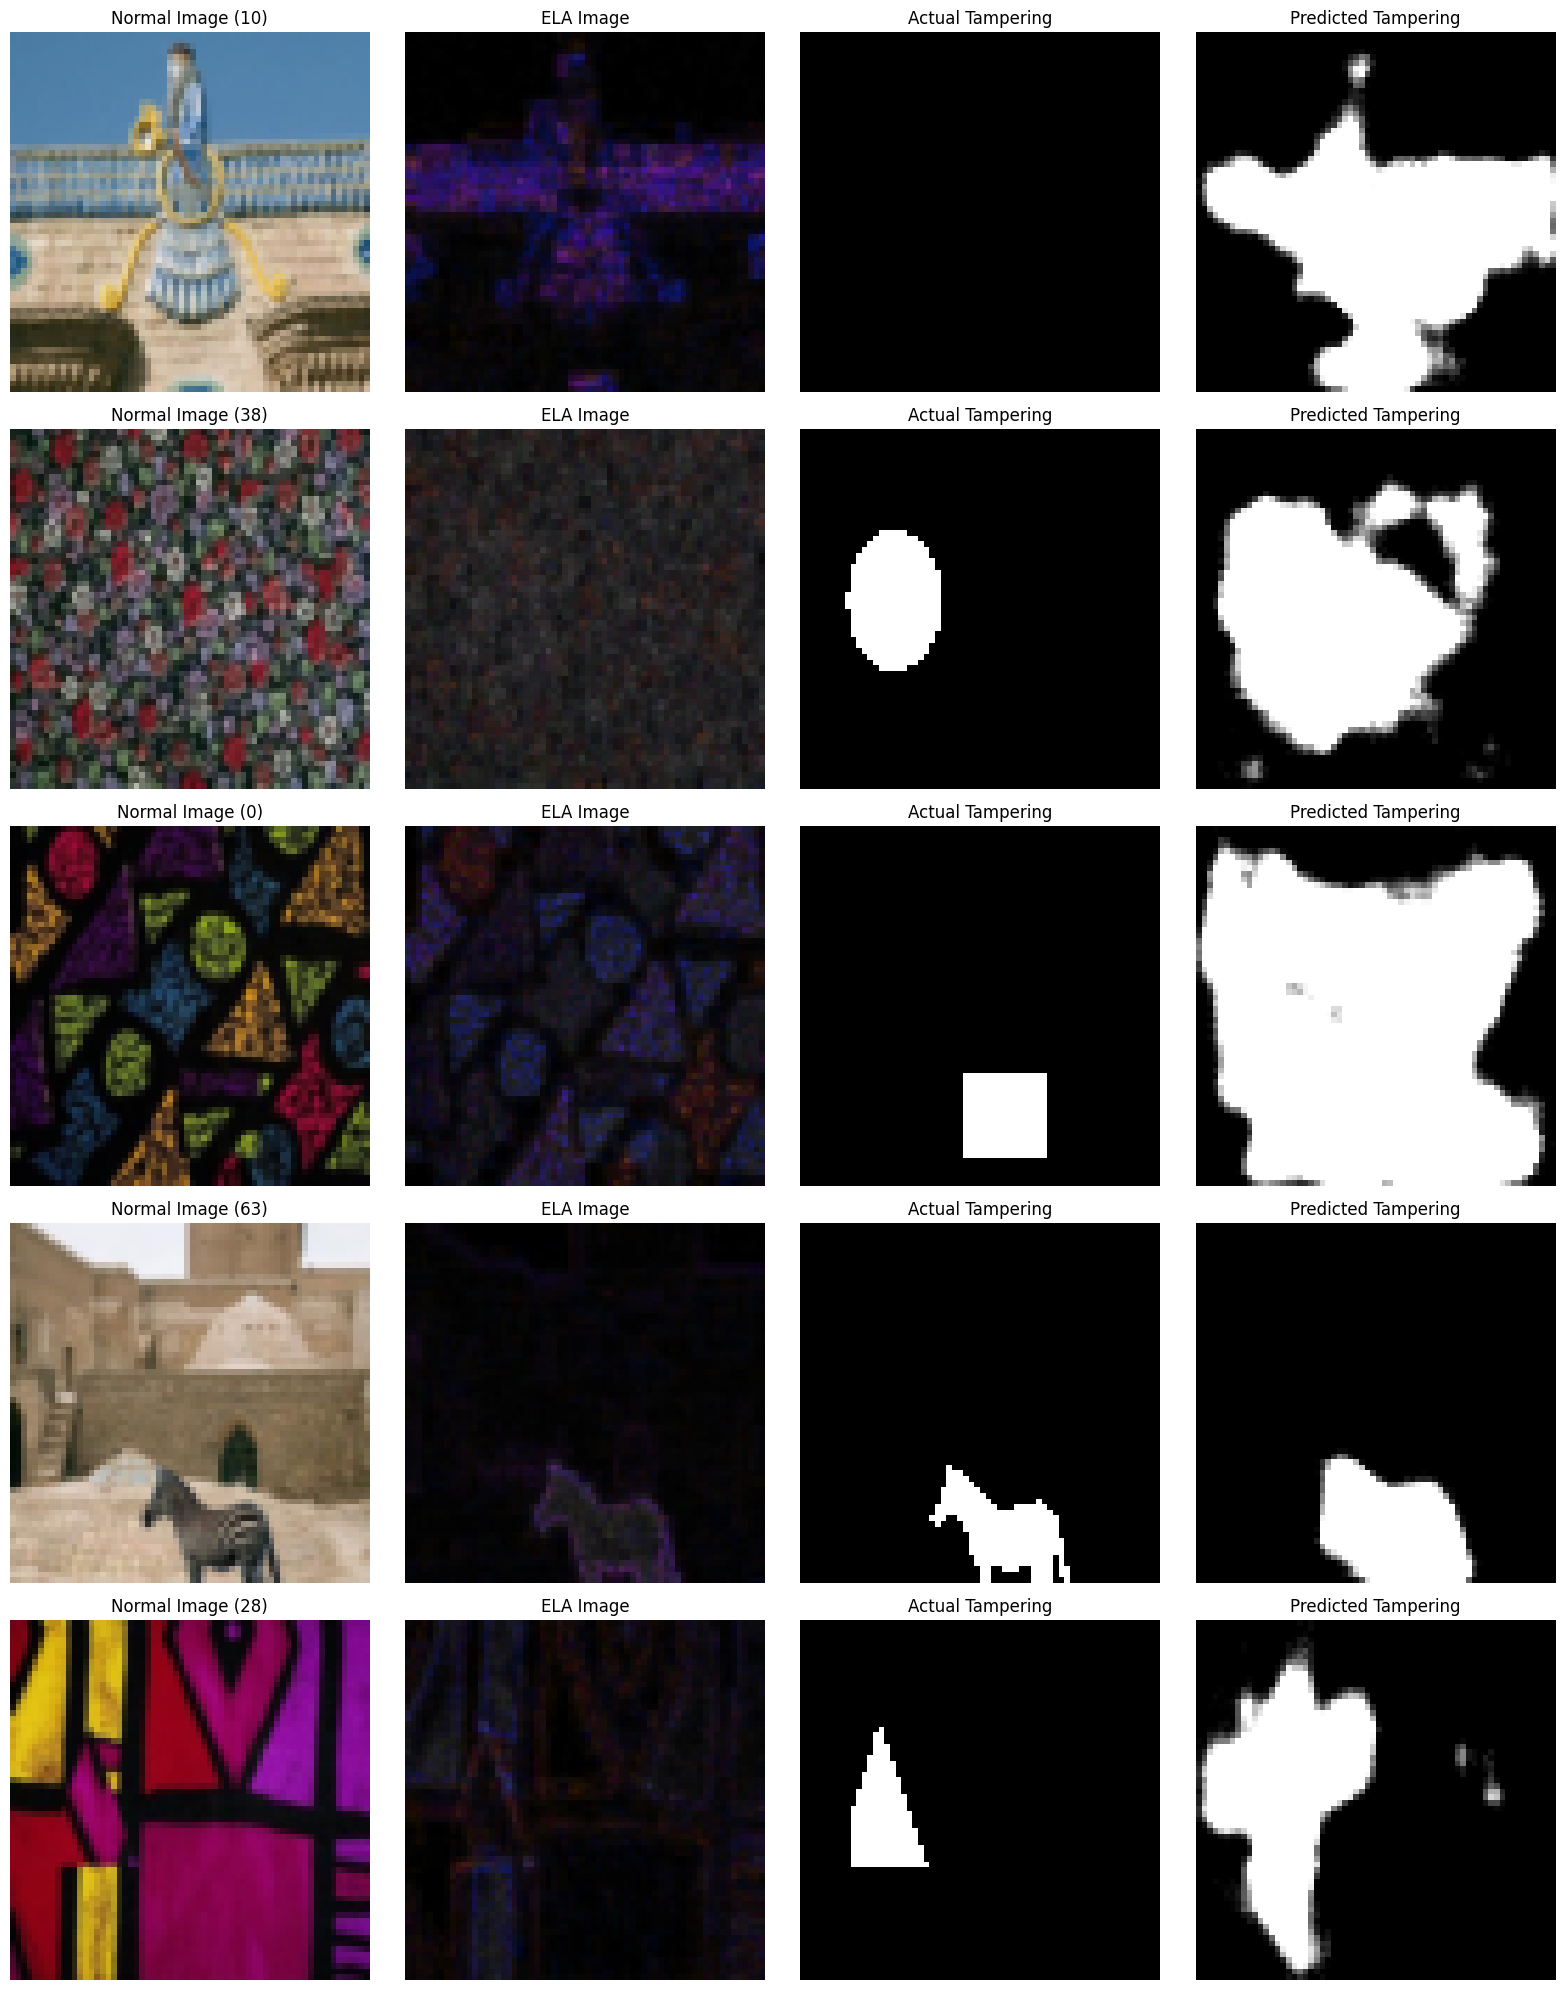

In [71]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Put model in eval mode
model.eval()

# Get one batch
images, masks = next(iter(train_dataloader))


with torch.no_grad():
    preds = model(images)

black_to_white = mcolors.LinearSegmentedColormap.from_list(
    "black_to_white",
    ["black", "white"]
)

batch_size = images.size(0)
num_samples = min(5, batch_size)
indices = random.sample(range(batch_size), num_samples)
plt.figure(figsize=(16, 4 * num_samples))

for i, idx in enumerate(indices):
    img = images[idx].cpu()
    gt  = masks[idx].cpu().squeeze()
    pr  = preds[idx].cpu().squeeze()

    # -------- Handle channel formats --------
    if img.ndim == 4 and img.shape[0] == 2:
        # (2, 3, H, W)
        normal = img[0]
        ela    = img[1]

    elif img.ndim == 3 and img.shape[0] == 6:
        # (6, H, W)
        normal = img[:3]
        ela    = img[3:]

    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")

    # Convert to HWC for plotting
    normal = normal.permute(1, 2, 0)
    ela    = ela.permute(1, 2, 0)

    # -------- Normal Image --------
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(normal)
    plt.title(f"Normal Image ({idx})")
    plt.axis("off")

    # -------- ELA Image --------
    plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(ela)
    plt.title("ELA Image")
    plt.axis("off")

    # -------- Ground Truth --------
    plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(gt, cmap="gray", vmin=0.0, vmax=1.0)
    plt.title("Actual Tampering")
    plt.axis("off")

    # -------- Prediction --------
    plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(pr, cmap=black_to_white, vmin=0.0, vmax=1.0)
    plt.title("Predicted Tampering")
    plt.axis("off")

plt.tight_layout()
plt.show()

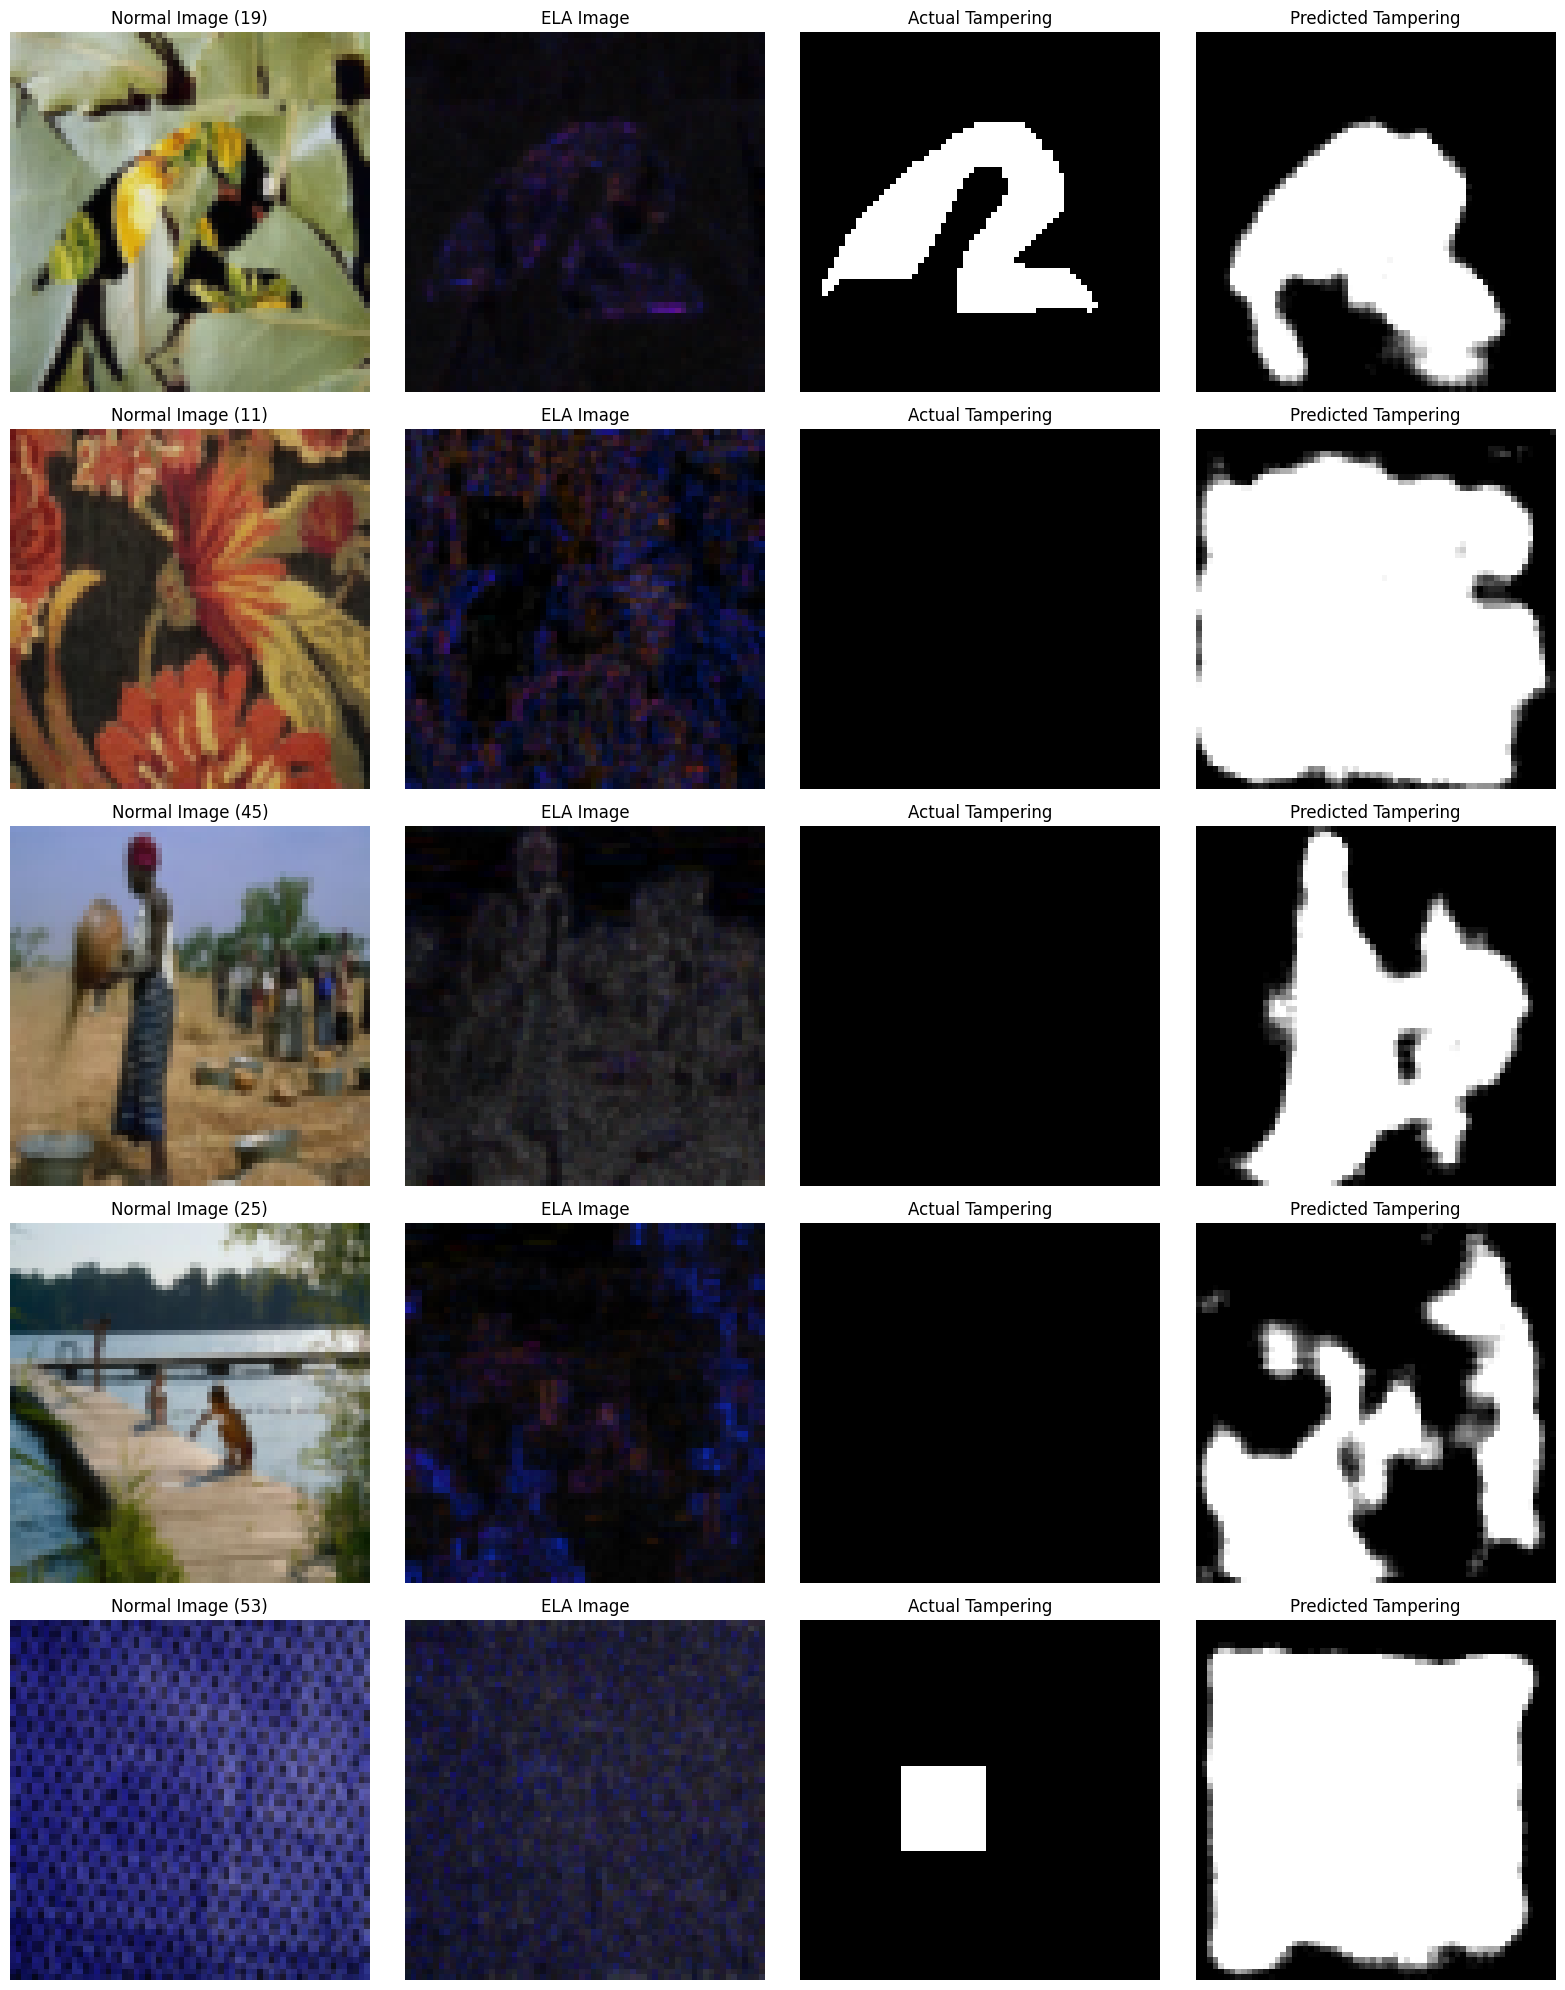

In [73]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Put model in eval mode
model.eval()

# Get one batch
images, masks = next(iter(test_dataloader))


with torch.no_grad():
    preds = model(images)

black_to_white = mcolors.LinearSegmentedColormap.from_list(
    "black_to_white",
    ["black", "white"]
)

batch_size = images.size(0)
num_samples = min(5, batch_size)
indices = random.sample(range(batch_size), num_samples)
plt.figure(figsize=(16, 4 * num_samples))

for i, idx in enumerate(indices):
    img = images[idx].cpu()
    gt  = masks[idx].cpu().squeeze()
    pr  = preds[idx].cpu().squeeze()

    # -------- Handle channel formats --------
    if img.ndim == 4 and img.shape[0] == 2:
        # (2, 3, H, W)
        normal = img[0]
        ela    = img[1]

    elif img.ndim == 3 and img.shape[0] == 6:
        # (6, H, W)
        normal = img[:3]
        ela    = img[3:]

    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")

    # Convert to HWC for plotting
    normal = normal.permute(1, 2, 0)
    ela    = ela.permute(1, 2, 0)

    # -------- Normal Image --------
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(normal)
    plt.title(f"Normal Image ({idx})")
    plt.axis("off")

    # -------- ELA Image --------
    plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(ela)
    plt.title("ELA Image")
    plt.axis("off")

    # -------- Ground Truth --------
    plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(gt, cmap="gray", vmin=0.0, vmax=1.0)
    plt.title("Actual Tampering")
    plt.axis("off")

    # -------- Prediction --------
    plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(pr, cmap=black_to_white, vmin=0.0, vmax=1.0)
    plt.title("Predicted Tampering")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [74]:
transform = transforms.Compose([transforms.Resize((SIZE,SIZE)),transforms.ToTensor()])
img = Image.open("tampered.jpg").convert("RGB")
rgb_tensor = transform(img)
ela_tensor = transform(convert_to_ela_image(img))
image_tensor = torch.cat([rgb_tensor,ela_tensor],dim=0)
image_tensor = image_tensor.unsqueeze(0)

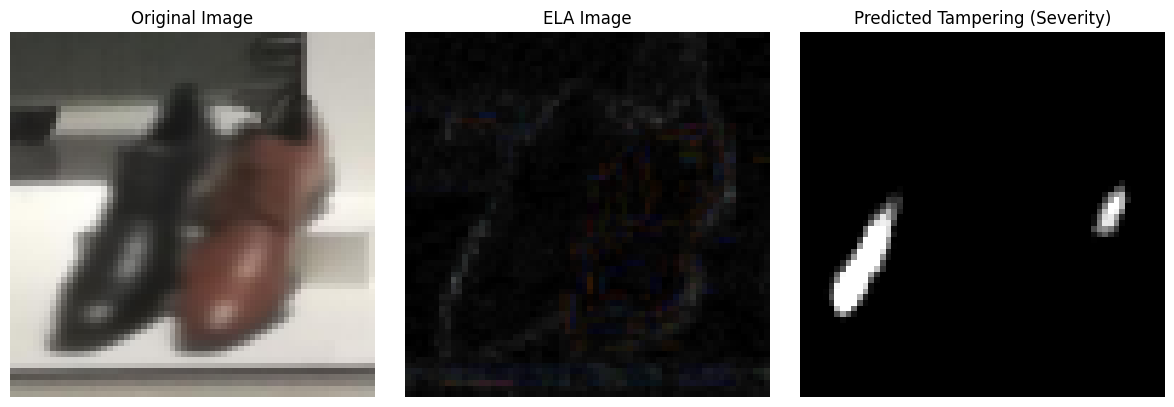

In [75]:
model.eval()

with torch.no_grad():
    pred = model(image_tensor)


# Prepare tensors for plotting
rgb_plot = rgb_tensor.permute(1, 2, 0).cpu()
ela_plot = ela_tensor.permute(1, 2, 0).cpu()
pred_plot = pred.squeeze().cpu()

plt.figure(figsize=(12, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(rgb_plot)
plt.title("Original Image")
plt.axis("off")

# ELA image
plt.subplot(1, 3, 2)
plt.imshow(ela_plot)
plt.title("ELA Image")
plt.axis("off")

# Predicted tampering severity
plt.subplot(1, 3, 3)
plt.imshow(pred_plot, cmap=black_to_white, vmin=0.0, vmax=1.0)
plt.title("Predicted Tampering (Severity)")
plt.axis("off")

plt.tight_layout()
plt.show()

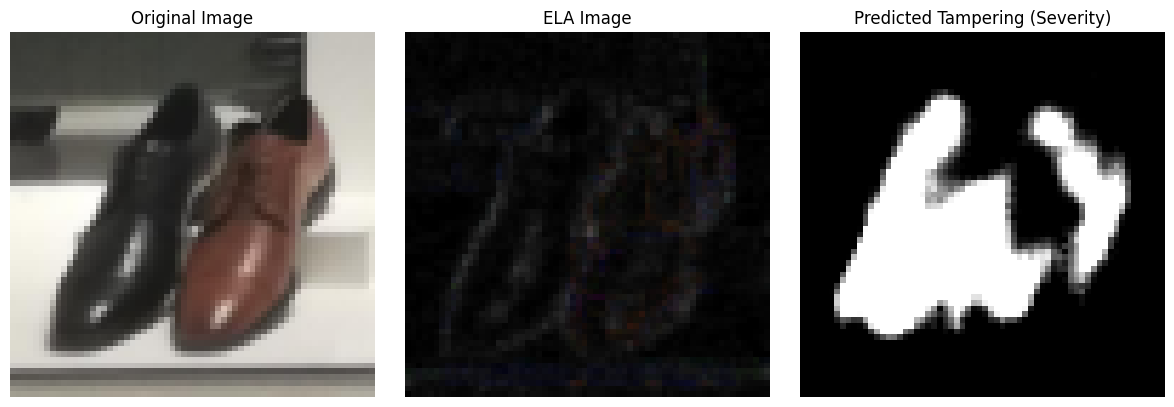

In [76]:
transform = transforms.Compose([transforms.Resize((SIZE,SIZE)),transforms.ToTensor()])
img = Image.open("original.jpg").convert("RGB")

def display_result(img,model):
    rgb_tensor = transform(img)
    ela_tensor = transform(convert_to_ela_image(img))
    image_tensor = torch.cat([rgb_tensor,ela_tensor],dim=0)
    image_tensor = image_tensor.unsqueeze(0)

    model.eval()

    with torch.no_grad():
        pred = model(image_tensor)


    # Prepare tensors for plotting
    rgb_plot = rgb_tensor.permute(1, 2, 0).cpu()
    ela_plot = ela_tensor.permute(1, 2, 0).cpu()
    pred_plot = pred.squeeze().cpu()

    plt.figure(figsize=(12, 4))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_plot)
    plt.title("Original Image")
    plt.axis("off")

    # ELA image
    plt.subplot(1, 3, 2)
    plt.imshow(ela_plot)
    plt.title("ELA Image")
    plt.axis("off")

    # Predicted tampering severity
    plt.subplot(1, 3, 3)
    plt.imshow(pred_plot, cmap=black_to_white, vmin=0.0, vmax=1.0)
    plt.title("Predicted Tampering (Severity)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

display_result(img,model)

In [77]:
#Save the model
PATH = "model_weights.pth"
torch.save(model.state_dict(), PATH)